# NMR-MRSI Training Data EDA

Explore the MATLAB training dataset stored at `/Users/adityarajan/Library/CloudStorage/Box-Box/NMR-MRSI-Data/trainingData`.
The files contain a `pars` array of shape `[6, 10, N]` with parameters: concentration, `T2`, `T2p`, phase `(phi)`, frequency shift `(df)`, and Gaussian linewidth `(g)` for 10 metabolites.


## 1. Setup

Import the necessary packages and verify the dataset directory.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import sys
sys.path.append('../src')
from utils.schema import default_schema

sns.set(style="whitegrid", context="talk")

data_dir = Path("/Users/adityarajan/Library/CloudStorage/Box-Box/NMR-MRSI-Data/trainingData")
assert data_dir.exists(), f"Dataset directory not found: {data_dir}"
print("Using data directory:", data_dir)
print("Schema: {} metabolites, {} params each, total dim {}".format(
    default_schema.n_metabolites, default_schema.n_metabolite_params, default_schema.total_dim))

Using data directory: /Users/adityarajan/Library/CloudStorage/Box-Box/NMR-MRSI-Data/trainingData


## 2. File inventory

List all `.mat` files and inspect their sizes.


In [8]:
mat_files = sorted(data_dir.glob("*.mat"))
print(f"Found {len(mat_files)} .mat files")
file_info = [
    {"filename": p.name, "size_GB": p.stat().st_size / 1e9} for p in mat_files
]
pd.DataFrame(file_info).sort_values("size_GB", ascending=False).style.format({"size_GB": "{:.2f}"})


Found 20 .mat files


,filename,size_GB
19,trdata_94T_dt200us_19.mat,1.63
9,trdata_94T_dt200us_09.mat,1.63
13,trdata_94T_dt200us_13.mat,1.63
12,trdata_94T_dt200us_12.mat,1.63
14,trdata_94T_dt200us_14.mat,1.63
1,trdata_94T_dt200us.mat,1.63
5,trdata_94T_dt200us_05.mat,1.63
7,trdata_94T_dt200us_07.mat,1.63
16,trdata_94T_dt200us_16.mat,1.63
6,trdata_94T_dt200us_06.mat,1.63


## 3. Inspect one sample file

Load a sample file and examine the `pars` variable plus any metabolite name metadata.


In [9]:
sample_path = mat_files[0]
print("Sample file:", sample_path.name)

def _h5py_read_string(dataset):
    try:
        data = dataset[()]
    except Exception:
        data = dataset
    if isinstance(data, bytes):
        return data.decode("utf-8", errors="ignore")
    if isinstance(data, np.ndarray):
        if data.dtype.kind in {"S", "U"}:
            parts = []
            for element in data.flatten():
                if isinstance(element, bytes):
                    parts.append(element.decode("utf-8", errors="ignore"))
                else:
                    parts.append(str(element))
            return "".join(parts).strip()
        return str(data)
    return str(data)

def load_mat_v73(path):
    result = {}
    with h5py.File(path, "r") as f:
        for key in f.keys():
            if key == "pars":
                result["pars"] = np.array(f["pars"])
            elif key.startswith("trdata"):
                group = f[key]
                if "Name" in group:
                    result.setdefault("names", []).append(_h5py_read_string(group["Name"]))
                elif "name" in group:
                    result.setdefault("names", []).append(_h5py_read_string(group["name"]))
    return result

mat = load_mat_v73(sample_path)
print("Loaded HDF5 MATLAB v7.3 file")

top_keys = sorted(mat.keys())
print("Top-level keys:", top_keys)

if "pars" not in mat:
    raise KeyError("pars not found in the sample file")
pars = mat["pars"]
print("pars type:", type(pars))
print("pars shape:", pars.shape)


Sample file: trdata_141T_dt160us.mat
Loaded HDF5 MATLAB v7.3 file
Top-level keys: ['pars']
pars type: <class 'numpy.ndarray'>
pars shape: (100000, 10, 6)


## 4. Extract metabolite names and reshape `pars`

Try to extract metabolite names from `trdata_*` entries and convert `pars` into a long-form DataFrame.


In [ ]:
metabolite_names = mat.get("names", [])
if len(metabolite_names) == 10:
    print("Extracted metabolite names:")
    print(metabolite_names)
else:
    metabolite_names = default_schema.metabolites
    print("Using default metabolite names from schema:")
    print(metabolite_names)

parameter_names = default_schema.metabolite_params

def normalize_pars_array(pars_array):
    if pars_array.ndim != 3:
        raise ValueError(f"Expected pars with 3 dimensions, got {pars_array.ndim}")
    if pars_array.shape[0] == len(parameter_names):
        return pars_array
    if pars_array.shape[2] == len(parameter_names):
        print("Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)")
        return np.transpose(pars_array, (2, 1, 0))
    if pars_array.shape[1] == len(parameter_names):
        print("Transposing pars from (metabolites, parameters, N) to (parameters, metabolites, N)")
        return np.transpose(pars_array, (1, 0, 2))
    raise ValueError(
        f"Could not normalize pars shape {pars_array.shape} to match {len(parameter_names)} parameters"
    )

pars = normalize_pars_array(pars)
assert pars.shape[0] == len(parameter_names), f"Expected pars shape first dimension {len(parameter_names)}, got {pars.shape[0]}"

def pars_to_dataframe(pars_array, metabolite_names, file_label=None, sample_limit=None):
    n_params, n_met, n_samples = pars_array.shape
    idx = np.arange(n_samples)
    rows = []
    for param_idx, param_name in enumerate(parameter_names):
        values = pars_array[param_idx]  # shape [n_met, n_samples]
        for met_idx in range(n_met):
            met_name = metabolite_names[met_idx] if met_idx < len(metabolite_names) else f"met_{met_idx+1}"
            met_values = values[met_idx] if values.ndim == 2 else np.array(values[met_idx]).reshape(-1)
            rows.append(pd.DataFrame({
                "parameter": param_name,
                "metabolite": met_name,
                "sample_idx": idx,
                "value": met_values,
                "file": file_label,
            }))
    df = pd.concat(rows, ignore_index=True)
    if sample_limit is not None and df["sample_idx"].max() + 1 > sample_limit:
        df = df[df["sample_idx"] < sample_limit].copy()
    return df

df_sample = pars_to_dataframe(pars, metabolite_names, file_label=sample_path.name, sample_limit=2000)
df_sample.head()

Using default metabolite names:
['met_1', 'met_2', 'met_3', 'met_4', 'met_5', 'met_6', 'met_7', 'met_8', 'met_9', 'met_10']
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)


,parameter,metabolite,sample_idx,value,file
0,concentration,met_1,0,0.390429,trdata_141T_dt160us.mat
1,concentration,met_1,1,0.769128,trdata_141T_dt160us.mat
2,concentration,met_1,2,0.125696,trdata_141T_dt160us.mat
3,concentration,met_1,3,1.269213,trdata_141T_dt160us.mat
4,concentration,met_1,4,1.300424,trdata_141T_dt160us.mat


## 5. Summary statistics for the sample file

Compute counts, means, and quantiles for each parameter and metabolite.


In [12]:
summary = df_sample.groupby(["parameter", "metabolite"]) ["value"].describe().reset_index()
summary = summary[["parameter", "metabolite", "count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
summary.head(20)


,parameter,metabolite,count,mean,std,min,25%,50%,75%,max
0,T2,met_1,2000.0,0.160836,0.029820,0.067199,0.141210,0.161335,0.180965,0.240000
1,T2,met_10,2000.0,0.095884,0.028995,0.030000,0.076240,0.095418,0.115494,0.171000
2,T2,met_2,2000.0,0.130552,0.037385,0.050000,0.104599,0.131833,0.158106,0.195000
3,T2,met_3,2000.0,0.101382,0.043077,0.040000,0.065784,0.099159,0.134288,0.180000
4,T2,met_4,2000.0,0.080492,0.026927,0.040000,0.059173,0.079604,0.099146,0.144000
5,T2,met_5,2000.0,0.086662,0.028164,0.040000,0.065692,0.085984,0.104968,0.154800
6,T2,met_6,2000.0,0.086372,0.028161,0.040000,0.065106,0.085404,0.106130,0.154800
7,T2,met_7,2000.0,0.148928,0.046573,0.040000,0.115803,0.148525,0.184456,0.225000
8,T2,met_8,2000.0,0.147624,0.046619,0.040000,0.115544,0.148851,0.181523,0.225000
9,T2,met_9,2000.0,0.200248,0.029724,0.104171,0.180087,0.200926,0.220859,0.280000


## 6. Distribution plots by parameter

Boxplots for each parameter by metabolite to inspect spread and outliers.


Text(0.5, 1.02, 'Parameter distributions by metabolite for one file')

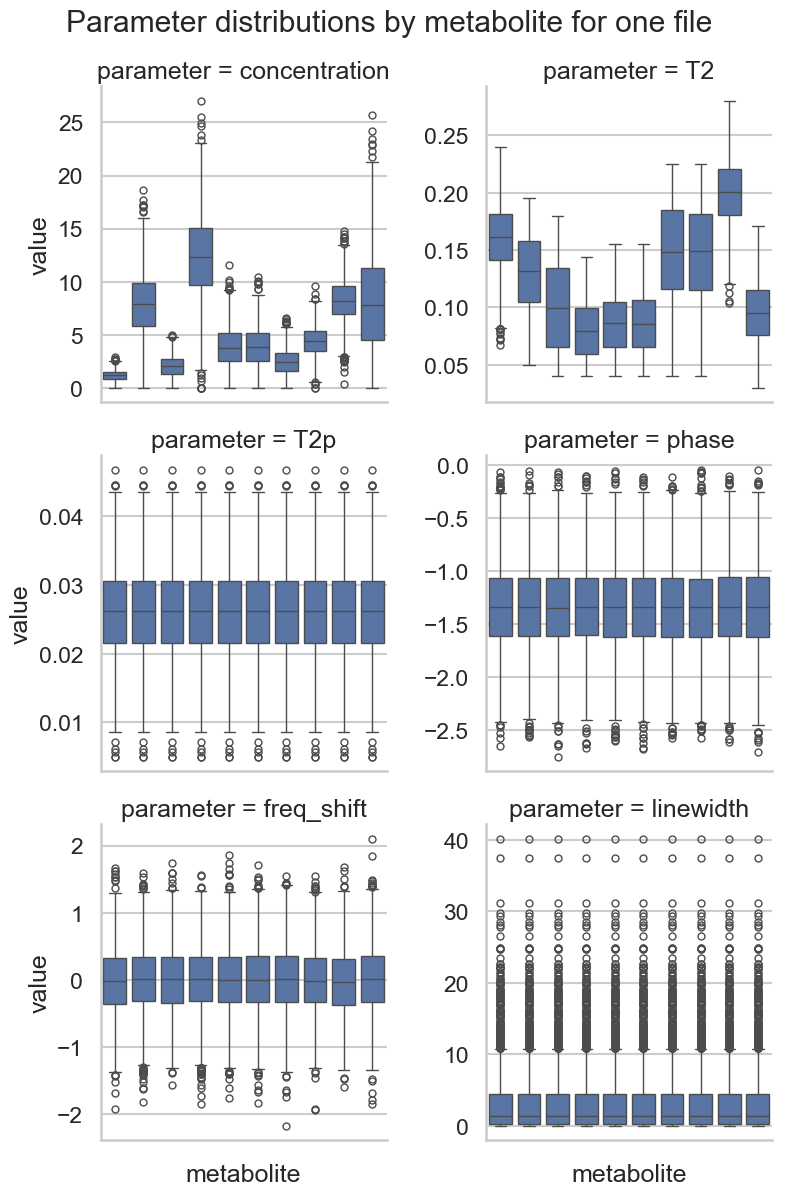

In [13]:
plot_order = metabolite_names
g = sns.catplot(
    data=df_sample,
    x="metabolite",
    y="value",
    col="parameter",
    kind="box",
    col_wrap=2,
    height=4,
    sharey=False,
    order=plot_order,
)
g.set_xticklabels(rotation=45, horizontalalignment="right")
g.fig.suptitle("Parameter distributions by metabolite for one file", y=1.02)


## 7. Pairwise correlation for one metabolite

Inspect the correlation structure of the six parameters for the first metabolite.


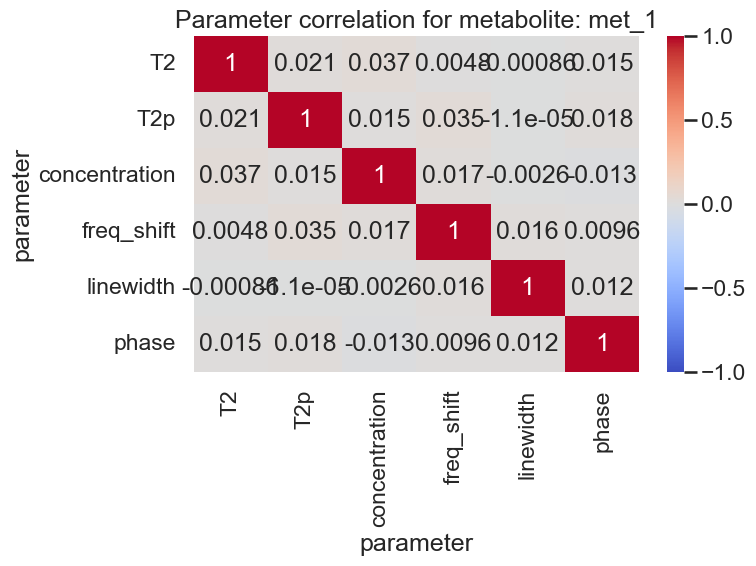

In [14]:
first_met = metabolite_names[0] if metabolite_names else "met_1"
df_corr = df_sample[df_sample["metabolite"] == first_met].pivot(index="sample_idx", columns="parameter", values="value")
corr = df_corr.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"Parameter correlation for metabolite: {first_met}")
plt.tight_layout()


## 8. Dataset-wide file summary

Compute mean values across all files for each parameter and metabolite.


In [ ]:
file_summaries = []
for p in mat_files:
    d = load_mat_v73(p)
    if "pars" not in d:
        continue
    pars_file = d["pars"]
    pars_file = normalize_pars_array(pars_file)
    if pars_file.shape[0] != len(parameter_names):
        continue
    means = np.mean(pars_file, axis=2)
    for param_idx, param_name in enumerate(parameter_names):
        for met_idx, met_name in enumerate(metabolite_names):
            file_summaries.append({
                "file": p.name,
                "parameter": param_name,
                "metabolite": met_name,
                "mean_value": float(means[param_idx, met_idx]),
            })
file_summary_df = pd.DataFrame(file_summaries)
print(f"Loaded summaries for {len(file_summary_df)} parameter/metabolite entries")
file_summary_df.head()

Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Transposing pars from (N, metabolites, parameters) to (parameters, metabolites, N)
Tran

,file,parameter,metabolite,mean_value
0,trdata_141T_dt160us.mat,concentration,met_1,1.201988
1,trdata_141T_dt160us.mat,concentration,met_2,7.903772
2,trdata_141T_dt160us.mat,concentration,met_3,2.008722
3,trdata_141T_dt160us.mat,concentration,met_4,12.404880
4,trdata_141T_dt160us.mat,concentration,met_5,3.831004


## 9. File-level variation for concentration

Visualize mean concentration by file and metabolite.


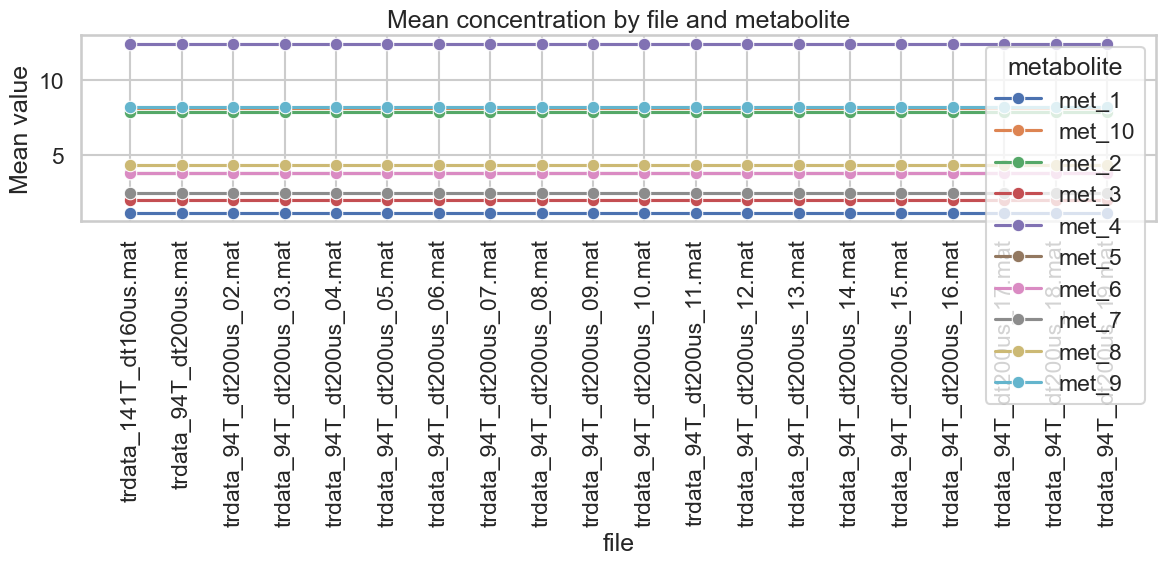

In [20]:
selected_param = "concentration"
if "parameter" not in file_summary_df.columns:
    raise ValueError("file_summary_df is missing the 'parameter' column. Check the file summary aggregation.")
plot_df = file_summary_df[file_summary_df["parameter"] == selected_param].copy()
if plot_df.empty:
    raise ValueError(f"No rows found for parameter {selected_param}. Available parameters: {file_summary_df['parameter'].unique()}")
plot_df = plot_df.sort_values(["metabolite", "mean_value"])
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x="file", y="mean_value", hue="metabolite", marker="o")
plt.xticks(rotation=90)
plt.title(f"Mean {selected_param} by file and metabolite")
plt.ylabel("Mean value")
plt.tight_layout()


## 10. Notes and next steps

- `pars` is the most important variable for initial modeling.
- The notebook shows file-level inventory, per-parameter distributions, and correlations.
- Next steps: inspect actual spectra if available, validate parameter ranges, and identify outliers in `phase`, `freq_shift`, and `linewidth`.


In [21]:
results_dir = Path("eda_results")
results_dir.mkdir(exist_ok=True)
print(f"Saving outputs to {results_dir.resolve()}")

# Save sample file summary statistics
summary.to_csv(results_dir / "sample_file_summary_statistics.csv", index=False)
print("✓ Saved sample_file_summary_statistics.csv")

# Save file-level summary
file_summary_df.to_csv(results_dir / "file_level_summary.csv", index=False)
print("✓ Saved file_level_summary.csv")

# Save sample data (first 5000 rows for inspection)
df_sample.head(5000).to_csv(results_dir / "sample_data_head.csv", index=False)
print("✓ Saved sample_data_head.csv")

# Recreate and save individual parameter distribution plots
for param in parameter_names:
    df_param = df_sample[df_sample["parameter"] == param]
    if df_param.empty:
        continue
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_param, x="metabolite", y="value")
    plt.title(f"Distribution: {param}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    filename = results_dir / f"distribution_{param}.png"
    plt.savefig(filename, dpi=100, bbox_inches="tight")
    plt.close()
    print(f"✓ Saved distribution_{param}.png")

# Save correlation heatmap for first metabolite
first_met = metabolite_names[0] if metabolite_names else "met_1"
df_corr = df_sample[df_sample["metabolite"] == first_met].pivot(index="sample_idx", columns="parameter", values="value")
corr = df_corr.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={"label": "Correlation"})
plt.title(f"Parameter correlation: {first_met}")
plt.tight_layout()
plt.savefig(results_dir / f"correlation_heatmap_{first_met}.png", dpi=100, bbox_inches="tight")
plt.close()
print(f"✓ Saved correlation_heatmap_{first_met}.png")

# Save file-level concentration plot
selected_param = "concentration"
plot_df = file_summary_df[file_summary_df["parameter"] == selected_param].copy()
if not plot_df.empty:
    plot_df = plot_df.sort_values(["metabolite", "mean_value"])
    plt.figure(figsize=(14, 6))
    sns.lineplot(data=plot_df, x="file", y="mean_value", hue="metabolite", marker="o")
    plt.xticks(rotation=90)
    plt.title(f"Mean {selected_param} by file and metabolite")
    plt.ylabel("Mean value")
    plt.tight_layout()
    plt.savefig(results_dir / "file_level_concentration.png", dpi=100, bbox_inches="tight")
    plt.close()
    print("✓ Saved file_level_concentration.png")

print(f"\nAll outputs saved to {results_dir.resolve()}")


Saving outputs to /Users/adityarajan/Projects/nmr-mrsi-transfer/notebooks/eda_results
✓ Saved sample_file_summary_statistics.csv
✓ Saved file_level_summary.csv
✓ Saved sample_data_head.csv
✓ Saved distribution_concentration.png
✓ Saved distribution_T2.png
✓ Saved distribution_T2p.png
✓ Saved distribution_phase.png
✓ Saved distribution_freq_shift.png
✓ Saved distribution_linewidth.png
✓ Saved correlation_heatmap_met_1.png
✓ Saved file_level_concentration.png

All outputs saved to /Users/adityarajan/Projects/nmr-mrsi-transfer/notebooks/eda_results
